In [7]:
# Install libraries
!pip install opencv-python numpy

In [18]:
# Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Download YOLOv3 weights, config, and class names
!wget https://pjreddie.com/media/files/yolov3.weights
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg
!wget https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names

In [9]:
# Upload input image
from google.colab import files
uploaded = files.upload()

Saving dog.jpg to dog.jpg


In [13]:
# Paths to YOLO files
weights_path = "yolov3.weights"
config_path = "yolov3.cfg"
names_path = "coco.names"

# Load network
net = cv2.dnn.readNet(weights_path, config_path)

# Load class labels
with open(names_path, "r") as f:
    classes = [line.strip() for line in f.readlines()]

# Read image
img = cv2.imread("dog.jpg")
height, width, channels = img.shape

In [14]:
# Create blob from image
blob = cv2.dnn.blobFromImage(img, 0.00392, (416, 416), (0, 0, 0), True, crop=False)

# Set input to network
net.setInput(blob)

# Get output layers
layer_names = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers()]

# Forward pass
outs = net.forward(output_layers)

In [15]:
class_ids = []
confidences = []
boxes = []

# Loop through detections
for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]

        # Filter only "dog" with confidence > 0.5
        if confidence > 0.5 and classes[class_id] == "dog":
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)

            # Rectangle coordinates
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)

            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

In [16]:
# Non-Max Suppression
indexes = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)

# Draw bounding boxes
for i in range(len(boxes)):
    if i in indexes:
        x, y, w, h = boxes[i]
        label = str(classes[class_ids[i]])
        confidence = confidences[i]
        color = (0, 255, 0)

        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
        cv2.putText(img, f"{label}: {confidence:.2f}", (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

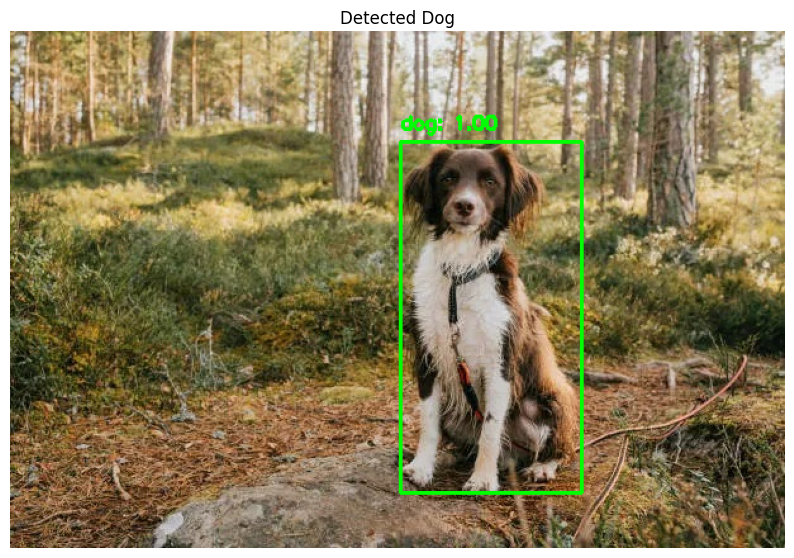

In [17]:
# Display detected image
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Detected Dog")
plt.show()